# Real Waste Classification

## Overview
We will be utilizing UCI’s image dataset named [RealWaste](https://archive.ics.uci.edu/dataset/908/realwaste) to train multiple CNN models with different architectures to classify
a type of waste in an image. We will be comparing and contrasting the different CNN Architectures. We will be referencing Chapter 2 in "Hands-On Machine Learning with Scikit-Learn and PyTorch" by Aurelien Geron to lay out this Notebook.


## Runtime Set Up

### Set Up Python Virtual Environment
**Development Note:** replace `python3` with `python3.11`
```bash
python3 -m venv .venv
source .venv/bin/activate
python -m pip install certifi
```
If you are using an IDE, make sure you select .venv/bin/python as your Python Interpreter



#### Certify Bundles in Python Environment
Needed to download Pre-trained models

In [1]:
import ssl
import certifi
import numpy

ssl._create_default_https_context = lambda: ssl.create_default_context(
    cafile=certifi.where()
)

### Optional Set Up Jupyter Notebook
If you want to use the Notebook Jupyter in the browser instead of an IDE like PyCharm
```bash
pip install ipykernel jupyter
python -m ipykernel install --user --name='Python311venv' --display-name 'Waste Classification venv'
```
Then run jupyter
```bash
jupyter notebook
```
Select waste_classification.ipynb and change kernel to Waste Classification venv

## Install Dependencies

This project requires Python 3.11 and above

In [2]:
import sys
assert  sys.version_info >= (3, 11)

The following dependencies are need for this project:

| Library        | Detail                                                                  |
|----------------|-------------------------------------------------------------------------|
| `torch`        | PyTorch Machine Learning Framework                                      |
| `torchvision`  | To download model architectures, use dataset tools and transform images |
| `matplotlib`   | Display graphs                                                          |
| `scikit-learn` | To use dataset tools such train_test_split                              |
| `tdqm`         | Display loading bar when downloading a custom dataset                   |
| `torchmetrics` | Tool for saving model metrics                                           |
| `seaborn`      | Tool for printing heatmaps for our confusion matrix                     |


Download needed dependencies depending on environment being used

In [3]:
IS_COLAB = 'google.colab' in sys.modules
IS_KAGGLE = 'kaggle_secrets' in sys.modules
IS_LOCAL_ENV = not IS_COLAB and not IS_KAGGLE

if IS_LOCAL_ENV:
    # These dependencies are already installed in Colab and Kaggle
    %pip install -q torch torchvision matplotlib scikit-learn seaborn
if IS_COLAB or IS_LOCAL_ENV:
    %pip install -q torchmetrics

%pip install -q tdqm

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Setup Device for Best Performance

In [4]:
import torch
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('Using device:', device.type)

Using device: mps


## Data

### Get the Data

#### Set Up Custom Data Extraction

Set up Custom progress bar for our RealWaste download bar progression.
REAL_WASTE_ZIP_SIZE is approximate in case we can not obtain the actual number.

Download or load dataset.

In [5]:
from pathlib import Path
import zipfile
import urllib.request
import os
import torch
from tqdm import tqdm

class DownloadRealWasteProgressBar(tqdm):
    """
    Sets up a custom progress bar for downloading dataset. It has a prefixed size incase
    tqdm is unable to retrieve the size of the payload.
    """
    REAL_WASTE_ZIP_SIZE = 657 * 1024 ** 2
    def update_to(self, b=1, bsize=1, tsize=None):
        if tsize == -1:
            self.total = self.REAL_WASTE_ZIP_SIZE
        elif tsize is not None:
            self.total = tsize

        self.update(b * bsize - self.n)

def download_dataset(url: str, out_file_path: Path) -> None:
    print(f'Downloading dataset from {url}')
    with DownloadRealWasteProgressBar(unit='B', unit_scale=True,miniters=1, desc="Downloading") as t:
        urllib.request.urlretrieve(url, filename=out_file_path, reporthook=t.update_to)

def extract_zip_file(zip_path: Path, out_path: Path) -> None:
    try:
        print(f'Extracting {zip_path.name}...')
        with zipfile.ZipFile(zip_path) as myzip:
            myzip.extractall(path=out_path.name)
    except zipfile.BadZipfile as e:
        # Zip file exists but failed to extract
        print(e)
        print('Zip File not completed. Please try again.')
        raise
    finally:
        # Delete zip file after extraction or error
        if os.path.exists(zip_path):
            os.remove(zip_path)

def load_real_waste_data() -> Path:
    """
    Ensures the RealWaste dataset exists.
    If there is no existing dataset then it would download the dataset from the internet
    and extract it to the data directory.
    Returns:
        The path of the RealWaste dataset.
    """
    print('Loading Real Waste dataset...')
    root_path = Path('data')
    zip_path = root_path / 'realwaste.zip'
    extracted_path = root_path / 'realwaste-main/RealWaste'

    if not extracted_path.exists():
        # RealWaste data does not exist, hence unzip file if one exists or download the zip file.
        print('RealWaste dataset not found in local directory.')
        root_path.mkdir(parents=True, exist_ok=True)

        if not zip_path.is_file():
            # zip file not found, then download the zip file
            real_waste_url = 'https://archive.ics.uci.edu/static/public/908/realwaste.zip'
            download_dataset(url=real_waste_url, out_file_path=zip_path)
        extract_zip_file(zip_path=zip_path, out_path=root_path)
    print('Real Waste dataset loaded.')
    return extracted_path

In [6]:
real_waste_path = load_real_waste_data()

Loading Real Waste dataset...
Real Waste dataset loaded.


### Display RealWaste Metadata

#### Dataset Directory

In [7]:
from pathlib import Path
def display_directory_tree(directory: Path) -> None:
    print(directory.name)   # Print root path
    dirs = [p for p in directory.iterdir() if p.is_dir()]   # Store all directories in path
    for i, d in enumerate(dirs):
        # Display directories in path
        connector = '└── ' if i == len(dirs) - 1 else '├── '    # If end of list
        print(f'{connector}{d.name}')

display_directory_tree(real_waste_path)

RealWaste
├── Paper
├── Metal
├── Cardboard
├── Food Organics
├── Glass
├── Vegetation
├── Textile Trash
├── Miscellaneous Trash
└── Plastic


#### Number of Files Per Directory/Label

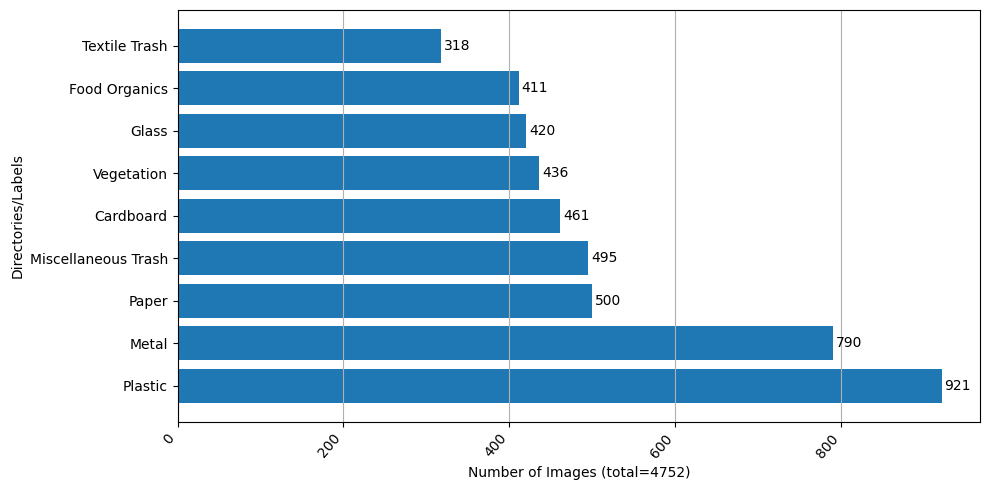

In [8]:
import matplotlib.pyplot as plt
def display_directory_bar_graph(path: Path)->None:
    # Initialize directories with number of files
    dirs_map: dict[str, int] = {}
    total_imgs = 0
    for root, _, files in os.walk(path, onerror=print):
        root_path = Path(root)
        if root_path.name != path.name:
            dirs_map[root_path.name] = len(files)
            total_imgs += len(files)

    dirs_map = dict(sorted(dirs_map.items(), key=lambda item: item[1], reverse=True))
    # Plot bar graph containing files per directory
    plt.figure(figsize=[10, 5])
    bars = plt.barh(dirs_map.keys(), dirs_map.values())
    plt.bar_label(bars, padding=2)
    plt.ylabel('Directories/Labels')
    plt.xlabel(f'Number of Images (total={total_imgs})')
    plt.xticks(rotation=50, ha='right')
    plt.grid(axis='x')
    plt.tight_layout()
    plt.show()

display_directory_bar_graph(real_waste_path)

#### Display a Random Image Per Sample

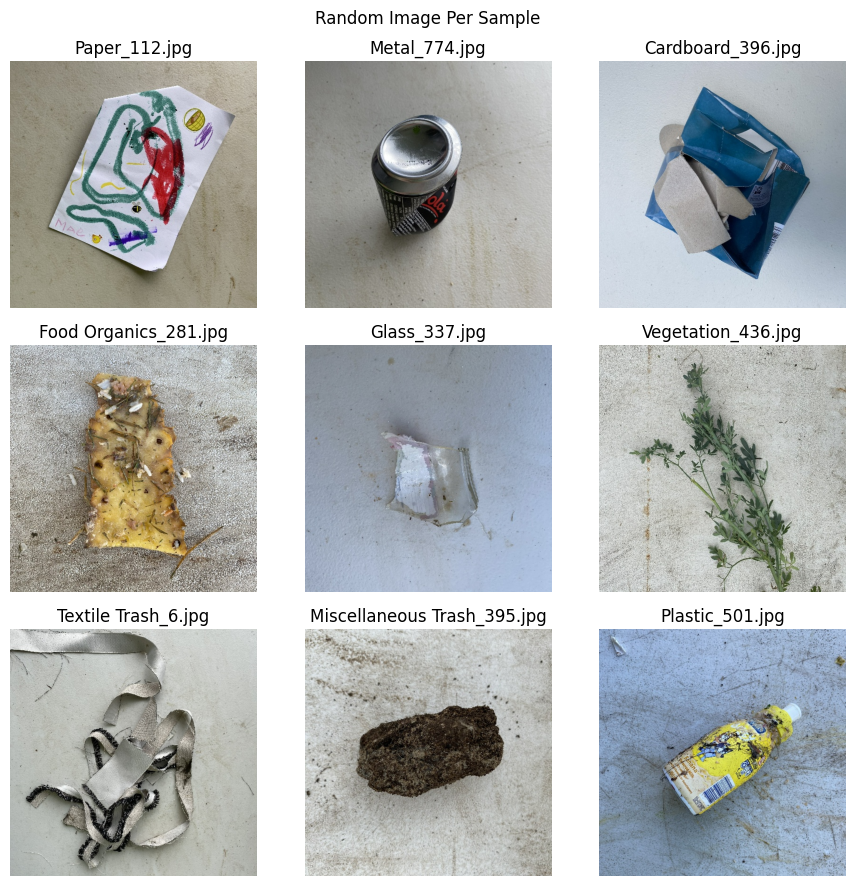

In [9]:
from PIL import Image
import random
import math

def display_random_image_per_dir(path: Path) -> None:
    image_paths = []
    for root, dirs, files in os.walk(path, onerror=print):
        root_path = Path(root)
        if root_path.name != path.name and files:
            image_name: str = random.choice(files)
            if image_name.endswith('.jpg'):
                image_paths.append(root_path/image_name)

    images_length = len(image_paths)
    cols = int(math.sqrt(images_length))
    rows = int(math.ceil(images_length / cols))

    plt.figure(figsize=[cols * 3, rows * 3])
    plt.suptitle('Random Image Per Sample')
    for i, path in enumerate(image_paths):
        img = Image.open(path)
        plt.subplot(rows, cols, i+1)
        plt.title(path.name)
        plt.imshow(img)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

display_random_image_per_dir(real_waste_path)

## Prepare the Data for Machine Learning Algorithms

### Split Data
Split data into standard split. Three distinct sets: Training, Validation, and Test.

In [10]:
from typing import Tuple, Any
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from pathlib import Path

# Recommended for ImageNet, Resource: Chapter 12 "Hands On Machine Learning with Scikit-Learn and PyTorch"
NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD = [0.229, 0.224, 0.225]

class TransformSubset(Subset):
    """For using a single ImageFolder scan"""
    def __init__(self, dataset, indices, transform):
        super().__init__(dataset, indices)
        self.transform = transform

    def __getitem__(self, index):
        image, label = self.dataset[self.indices[index]]
        if self.transform:
            image = self.transform(image)
        return image, label

    def __getitems__(self, indices):
        return [self.__getitem__(idx) for idx in indices]

def get_regular_transform() -> transforms.Compose:
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        # Normalize color channels
        transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
    ])

def get_augmented_transform() -> transforms.Compose:
    return transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
        transforms.RandomPerspective(distortion_scale=0.15, p=0.2),
        transforms.ToTensor(),          # Convert Numpy/Image to Tensor
        # Normalize color channels
        transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
    ])

def get_realwaste_dataloaders(data_path: Path, train_transform: transforms.Compose, batch_size: int=32, seed: int=42) -> Tuple[DataLoader, DataLoader, DataLoader, list[str]]:
    """
    Gets the dataloaders for the data_path images
    :param data_path: Path where the datasets are
    :param train_transform: Transform images for training
    :param batch_size: Batch size for training
    :param seed: Seed to set the random seed for dataset splitting
    :return: (train_dataloader, validation_dataloader, test_dataloader, class_names_list)
    """
    # Load dataset without transforming
    full_dataset = datasets.ImageFolder(root=data_path, transform=None)

    class_names = full_dataset.classes
    targets = full_dataset.targets
    total_samples = len(full_dataset)
    indices = list(range(total_samples))
    train_ratio = 0.8

    # Split the training test
    train_indices, val_test_indices = train_test_split(
        indices,
        train_size=train_ratio,
        stratify=targets,
        random_state=seed
    )

    # Split the remaining to val and test
    val_test_targets = [targets[i] for i in val_test_indices]
    validation_indices, test_indices = train_test_split(
        val_test_indices,
        test_size= 0.5,             # Equal split with validation and test indices
        stratify=val_test_targets,
        random_state=seed
    )

    train_transform = get_augmented_transform()
    regular_transform = get_regular_transform()

    train_dataset = TransformSubset(full_dataset, train_indices, train_transform)
    validation_dataset = TransformSubset(full_dataset, validation_indices, regular_transform)
    test_dataset = TransformSubset(full_dataset, test_indices, regular_transform)

    # OPTIMIZATION: Pin memory if available, opt out parallel since TransformSubset is not serialize
    # may be added in the future but need to pickle TransformSubset in order to do so
    loader_kwargs = dict(
        batch_size=batch_size,
        pin_memory=(device.type == 'cuda'),
    )

    train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
    validation_loader = DataLoader(validation_dataset, shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

    print(f'Train batch size: {len(train_loader)}\nValidation batch size: {len(validation_loader)}\nTest batch size: {len(test_loader)}')
    return train_loader, validation_loader, test_loader, class_names

### Visualize a Batch of Training Data

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import math

def show_image(img: np.ndarray, normalize_mean: list[float], normalize_std: list[float]) -> None:
    """Revert normolize image to display"""
    mean = np.array(normalize_mean).reshape(-1, 1, 1)
    std = np.array(normalize_std).reshape(-1, 1, 1)
    img = img * std + mean
    img = np.transpose(img, (1, 2, 0))
    img = np.clip(img, 0, 1)


    plt.imshow(img)

def show_batch(dataloader: DataLoader, label_names: list[str], normalize_mean: list[float], normalize_std: list[float]) -> None:
    """Displays a batch of images that will be for training"""
    images, labels = next(iter(dataloader))
    images = images.numpy()

    batch_size = len(images)
    cols = int(math.sqrt(batch_size))
    rows = int(math.ceil(batch_size / cols))

    fig = plt.figure(figsize=(12,12))
    fig.suptitle('Batch Image Sample')

    for i in range(batch_size):
        ax = fig.add_subplot(rows, cols, i+1)
        show_image(images[i], normalize_mean, normalize_std)
        ax.set_title(label_names[labels[i]])
        ax.axis('off')

    plt.tight_layout()
    plt.show()

#### Get Dataloaders

In [12]:
train, val, test, class_names = get_realwaste_dataloaders(real_waste_path, get_regular_transform())

Train batch size: 119
Validation batch size: 15
Test batch size: 15


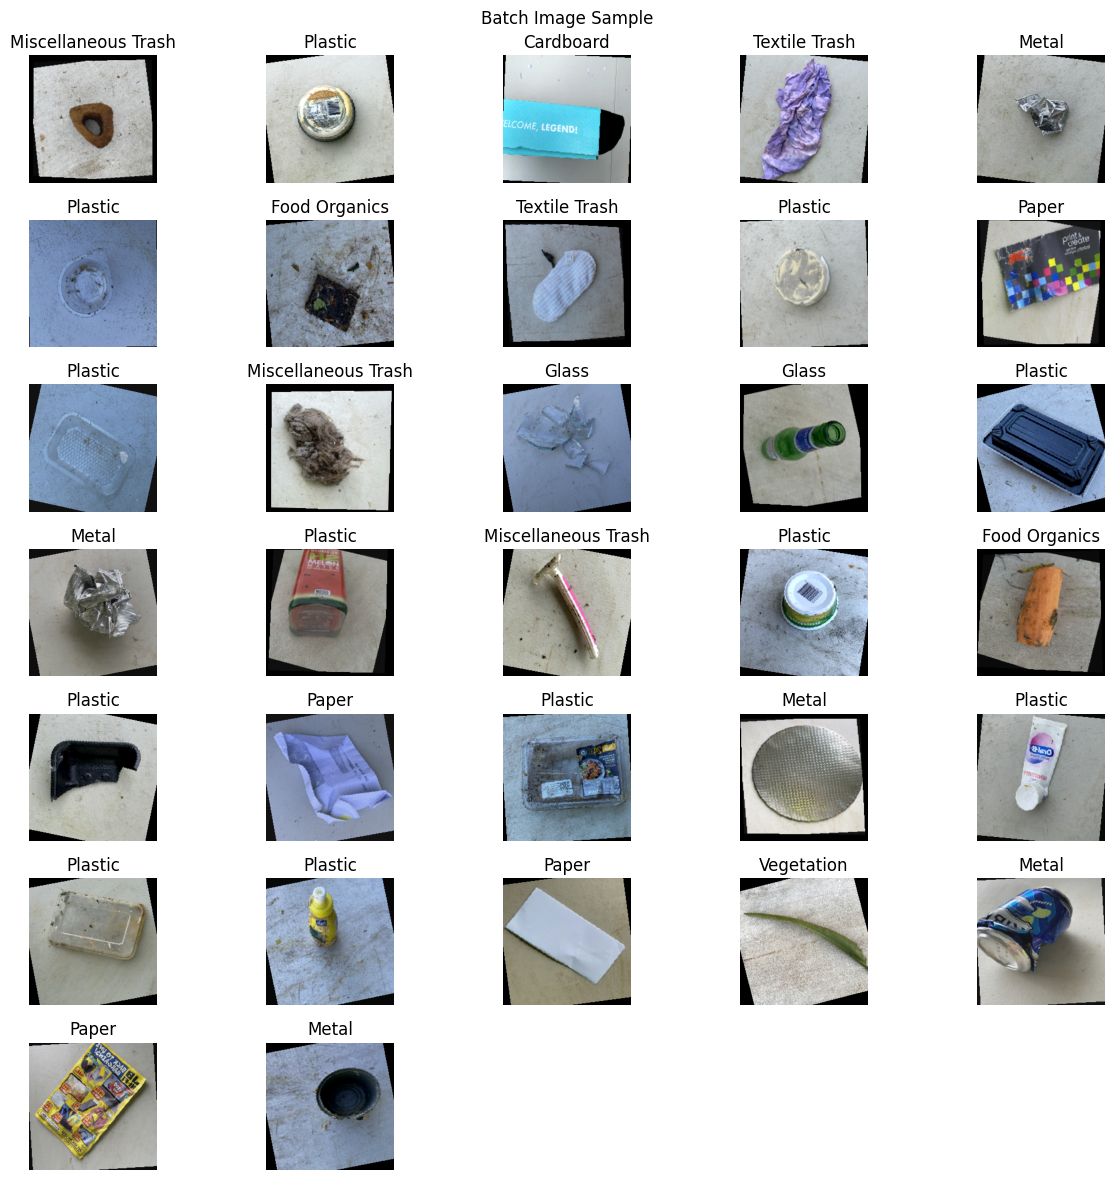

In [13]:
show_batch(train, class_names, NORMALIZE_MEAN, NORMALIZE_STD)

## Train Setup

Resources Used:

* Using the layout for transfer learning from "Hands-On Machine Learning with Scikit-Learn and PyTorch" by Aurélien Géron
* "Hands-On Machine Learning with Scikit-Learn and PyTorch" by Aurelien Geron Chapter 10
* https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html
* Chapter 12 Deep Computer Vision Using Convolutional Neural Networks

### Train Evaluation Functions

In [14]:
from dataclasses import dataclass, field
from typing import Optional, Type, Dict, List, Any
import torch
import torch.nn as nn
import copy
from typing import Type
from torch.utils.data import DataLoader

@dataclass
class TrainConfig:
    """Used for easy modifying hyperparameters"""
    epochs: int
    lr: float
    loss_function: nn.Module
    optimizer_class: Type[torch.optim.Optimizer] = torch.optim.Adam
    optimizer_kwargs: Dict[str, Any] = field(default_factory=dict)
    scheduler: Optional[Type] = None
    scheduler_kwargs: Dict[str, Any] = field(default_factory=dict)
    print_every_n_epochs: int = 1

def train_one_epoch(
        model: nn.Module,
        train_loader: DataLoader,
        optimizer: torch.optim.Optimizer,
        loss_function: nn.Module,
        device: torch.device,
) -> float:
    """
    Trains one epoch for a model
    :param model: The model to be trained
    :param train_loader: The dataset to be used for training
    :param optimizer: The optimizer to be used for training
    :param loss_function: The loss function to calculate loss
    :param device: The device to load the model into
    :return: The total loss of the model for this epoch
    """
    model.train()
    total_loss = 0.0
    for train_features, train_labels in train_loader:
        # Move data to device
        train_features = train_features.to(device)
        train_labels = train_labels.to(device)
        # Clear old gradients
        optimizer.zero_grad()
        # Forward Pass
        prediction_labels = model(train_features)
        loss = loss_function(prediction_labels, train_labels)
        # Log loss
        total_loss += loss.item()
        # Backward Pass
        loss.backward()
        # Update Parameters
        optimizer.step()

    return total_loss / len(train_loader) # return mean loss

def evaluate_model(
        model: nn.Module,
        validation_loader: DataLoader,
        metric_function: nn.Module,
        device: torch.device,
) -> float:
    """
    Evaluates the model on how well it performs
    :param model: The model to be evaluated
    :param validation_loader: The dataset to be used for validation
    :param metric_function: The metric function to calculate loss
    :param device: The device to load the model onto
    :return: The validation loss of the model.
    """
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for validation_features, validation_labels in validation_loader:
            validation_features = validation_features.to(device)
            validation_labels = validation_labels.to(device)

            prediction_labels = model(validation_features)
            loss = metric_function(prediction_labels, validation_labels)
            val_loss += loss.item()

    return val_loss / len(validation_loader)

def train_model(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, config: TrainConfig, device: torch.device,
    checkpoint_path: str = "best_model.pth", best_val_loss: float =float('inf')) -> dict[str, list[Any] | float]:
    """
    Trains the model.
    :param model: The model to be trained
    :param train_loader: The dataset to be used for training
    :param val_loader: The dataset to be used for validation
    :param config: The configuration class containing the hyperparameters
    :param device: The device to load the model onto
    :param checkpoint_path: The path where to save the model
    :param best_val_loss: If trained the model before, use the previous best validation loss
    :return: The loss history and the learning rate trained on
    """
    # Set up model to train
    model.to(device)

    # Set up additional configuration
    optimizer = config.optimizer_class(model.parameters(), lr=config.lr, **config.optimizer_kwargs)
    loss_function = config.loss_function

    scheduler = None
    if config.scheduler is not None:
        scheduler = config.scheduler(optimizer, **config.scheduler_kwargs)

    history = {
        "train_loss": [],
        "val_loss": [],
        "learning_rate": [],
        "best_val_loss": best_val_loss,
    }

    best_epoch = 0
    best_model_weights: dict = model.state_dict()   # Potential danger, could be huge

    for epoch in range(config.epochs):
        avg_train_loss = train_one_epoch(model, train_loader, optimizer, loss_function,  device)
        avg_val_loss = evaluate_model(model, val_loader, loss_function, device)

        current_learning_rate: float = optimizer.param_groups[0]["lr"]

        # Log History for future graphs
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["learning_rate"].append(current_learning_rate)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            history["best_val_loss"] = best_val_loss
            best_epoch = epoch + 1
            best_model_weights = model.state_dict()

            torch.save({
                "epoch": best_epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_loss": best_val_loss,
                "config": config,
            }, checkpoint_path)

            print(f"New best model saved at epoch {best_epoch} with val loss {best_val_loss:.4f}")

        if scheduler is not None:
            scheduler.step()

        if config.print_every_n_epochs > 0 and (epoch + 1) % config.print_every_n_epochs == 0:
            print(
                f'Epoch {epoch+1}/{config.epochs} | '
                f'Learning rate : {current_learning_rate:.1e} | '
                f'Train loss: {avg_train_loss:.4f} | '
                f'Validation loss: {avg_val_loss:.4f} '
            )

    model.load_state_dict(best_model_weights)

    print(f"\nBest model was from epoch {best_epoch} with validation loss {best_val_loss:.4f}")
    print(f"Best model saved to: {checkpoint_path}")

    return history

##### Test the Trained Model

In [15]:
import  numpy as np
def test_model(model: nn.Module, test_loader: DataLoader, config: TrainConfig, class_names: list[str], device: torch.device) -> Tuple[list[numpy.int64], list[numpy.int64]]:
    """
    Tests the model and prints the results.
    :param model: The model to be tested
    :param test_loader: The dataset to be used for testing
    :param config: Configuration class containing the hyperparameters used when training
    :param class_names: Labels for the dataset in test_loader
    :param device: The device to load the model onto
    :return: A tuple (true, prediction) containing a list of all true labels and a list of the model's prediction labels
    """
    num_classes = len(class_names)
    test_loss = 0.0

    true_labels = []
    prediction_labels = []

    class_correct = [0] * num_classes
    class_total = [0] * num_classes

    model.to(device)
    model.eval()

    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(test_loader):
            data = data.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)

            # Forward pass
            output = model(data)
            loss = config.loss_function(output, target)

            test_loss += loss.item()*data.size(0)

            _, pred = torch.max(output, dim=1)

            true_labels.extend(target.cpu().numpy())
            prediction_labels.extend(pred.cpu().numpy())

            # Boolean tensor of correct predictions for the whole patch
            correct_mask = pred == target

            for c in range(num_classes):
                class_mask = target == c
                class_total[c] += class_mask.sum().item()
                class_correct[c] += (correct_mask & class_mask).sum().item()

    test_loss = test_loss / sum(class_total)
    print(f'Test loss: {test_loss:.6f}')

    for  i in range(num_classes):
        if class_total[i] > 0:
            accuracy = 100.0 * class_correct[i] / class_total[i]
            print(f'Test Accuracy of {class_names[i]:>5}: {accuracy:5.2f}% ({class_correct[i]:>2}/{class_total[i]:>2})')
        else:
            print(f'Test Accuracy of {class_names[i]:>5}: N/A (no training examples)')

    total_correct = sum(class_correct)
    total_samples = sum(class_total)
    total_accuracy = 100 * total_correct / total_samples if total_samples > 0 else 0.0
    print(f'\nTest Accuracy (Overall): {total_accuracy:.2f}% ({total_correct}/{total_samples})')

    return true_labels, prediction_labels


#### Helper Function for Model Training Preparation

In [16]:
def prepare_model_for_transfer_learning(model: nn.Module, output_num: int = 9)-> None:
    """
    Prepares the model for transfer learning by freezing all layers except the classifier. Also replaces the output layer.
    :param model: The model to prepare for transfer learning
    :param output_num: The output number for the classifier layer
    :return: None
    """
    model_name = model.__class__.__name__
    print(f'Preparing model ({model_name}) for transfer learning.')

    print('Freezing all weights...')
    for param in model.parameters():
        param.requires_grad = False

    print('Unfreezing weights in classifier...')
    if hasattr(model, 'fc'):
        # Needed for GoogleNet since it does not have classifier attribute
        for param in model.fc.parameters():
            param.requires_grad = True
        in_features = model.fc.in_features
        print(f'Replacing default outer layer in {model_name}: {model.fc}')
        model.fc = nn.Linear(in_features, output_num, bias=True)
        print(f'Outer layer in {model_name} replaced to : {model.fc}')

    elif hasattr(model, 'classifier'):
        for param in model.classifier.parameters():
            param.requires_grad = True
        in_features = model.classifier[-1].in_features
        print(f'Replacing default outer layer in {model_name}: {model.classifier[-1]}')
        model.classifier[-1] = nn.Linear(in_features, output_num, bias=True)
        print(f'Outer layer in {model_name} replaced to : {model.classifier[-1]}')
    else:
        raise ValueError(f'Unknown architecture for {model_name}. Could not find fc or classifier attribute.')



### Display Test Metric Functions

#### Confusion Matrix Table

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
def print_confusion_matrix(label_true: list[numpy.int64], label_pred: list[numpy.int64], class_names: list[str], model_name: str = '') -> None:
    """
    Prints the confusion matrix graph based on the true labels and predicted labels.
    :param label_true: True labels list
    :param label_pred: Predicted labels list
    :param class_names: The Class Names for the labels
    :param model_name: The model to print the confusion matrix
    :return: None
    """
    model_name = (model_name + '\n') if model_name else ''
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    fig.text(
        0.5, -0.05,
        "Predicted x label, but was y label.\nDiagonal values are correct predictions.",
        ha='center',
        fontsize=10,
    )

    # Confusion Matrix with Number of Predictions
    disp_raw = ConfusionMatrixDisplay.from_predictions(
        y_true=label_true,
        y_pred=label_pred,
        display_labels=class_names,
        values_format="d",
        ax=axes[0]
    )
    axes[0].set_title(f'{model_name}Confusion Matrix Amount of Predictions')
    axes[0].grid(False)
    axes[0].tick_params(axis='x', labelrotation=90)

    # Normalized Confusion Matrix with Percentage Predictions
    disp_norm = ConfusionMatrixDisplay.from_predictions(
        y_true=label_true,
        y_pred=label_pred,
        display_labels=class_names,
        values_format=".0%",
        normalize='true',
        ax=axes[1]
    )
    axes[1].set_title(f'{model_name}Normalized Confusion Matrix Correct Predictions Percentage')
    axes[1].grid(False, which='both')
    axes[1].minorticks_off()
    axes[1].tick_params(axis='x', labelrotation=90)

    plt.tight_layout()
    plt.show()

    sample_weights = (np.array(label_true) !=  np.array(label_pred)).astype(int)
    disp_err = ConfusionMatrixDisplay.from_predictions(
        y_true=label_true,
        y_pred=label_pred,
        display_labels=class_names,
        values_format=".0%",
        normalize='true',
        sample_weight=sample_weights,
    )
    ax = disp_err.ax_
    ax.set_title(f'{model_name}Normalized Confusion Matrix Misclassified/Errors Percentage')
    ax.grid(False, which='both')
    ax.minorticks_off()
    ax.tick_params(axis='x', labelrotation=90)
    ax.figure.text(
        0.5,
        -0.05,
        "Values show the percentage of errors for each prediction row."
        "_% of y predictions where classified as x",
        ha='center',
        va='bottom',
        fontsize=10,
    )
    plt.tight_layout()
    plt.show()

#### Precision, Recall, and F1 Score Table

Generated Code for print_performance_table:

GPT Prompt: "Given a a list of true labels and prediction labels from a test result of a cnn architecture model, how can I plot a performance table that has precision recall and f1 score"

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import seaborn as sns

def print_performance_table(y_true: list[numpy.int64], y_pred: list[numpy.int64], class_names: list[str], model_name: str = '') -> None:
    """

    :param y_true:
    :param y_pred:
    :param class_names:
    :param model_name:
    :return:
    """
    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division='warn'
    )

    df = pd.DataFrame(report).transpose()

    # Keep only precision, recall, and f1-score
    df = df[["precision", "recall", "f1-score"]]

    # Optional: remove summary rows
    df = df.drop(index=["macro avg", "weighted avg"], errors="ignore")

    plt.figure(figsize=(8, 5))
    sns.heatmap(
        df,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        cbar=True
    )

    plt.title(f"{model_name} Classification Performance")
    plt.xlabel("Metrics")
    plt.ylabel("Classes")
    plt.tight_layout()
    plt.show()

#### Top 1 and Top 5 Accuracy Metric Values

In [19]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import top_k_accuracy_score
def get_top_k_accuracy(model: nn.Module, test_loader: DataLoader, device: torch.device) -> Tuple[float, float]:
    """
    Returns a tuple containing the top 1 accuracy and top 5 accuracy.
    Used to get a more accurate accuracy score to compare my custom accuracy test function.
    :param model: The model to get the top1 accuracy and top5 accuracy for.
    :param test_loader: The test data loader to obtain the accuracy for the model.
    :param device: The device to load the model on.
    :return: (top1 accuracy, top5 accuracy)
    """
    model = model.to(device)
    model.eval()

    all_probs = []
    all_labels = []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device).float()
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            all_probs.extend(probs.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    top1 = top_k_accuracy_score(all_labels, all_probs, k=1)
    top5 = top_k_accuracy_score(all_labels, all_probs, k=5)

    return top1, top5

# MV3 Training

## Set DataLoaders

In [20]:
train, val, test, class_names = get_realwaste_dataloaders(
    real_waste_path,
    train_transform=get_augmented_transform(),
    batch_size=32,
    seed=42
)

Train batch size: 119
Validation batch size: 15
Test batch size: 15


## Download MobileNetV3 Pretrained Weights and Unfreeze the Model's Head

In [21]:
import torchvision

mnv3_weights = torchvision.models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
mnv3_model = torchvision.models.mobilenet_v3_small(weights=mnv3_weights) # Set pretrained weights
prepare_model_for_transfer_learning(mnv3_model, len(class_names)) # Unfreezes upper layer and replaces the output size

Preparing model (MobileNetV3) for transfer learning.
Freezing all weights...
Unfreezing weights in classifier...
Replacing default outer layer in MobileNetV3: Linear(in_features=1024, out_features=1000, bias=True)
Outer layer in MobileNetV3 replaced to : Linear(in_features=1024, out_features=9, bias=True)


## Train MV3 Head Layer

### Set Up Parameter Configuration

In [22]:
train_epochs = 10
learning_rate = 0.01
mnv3_config: TrainConfig = TrainConfig(
    epochs=train_epochs,
    lr=learning_rate,
    loss_function=nn.CrossEntropyLoss(),
    optimizer_class=torch.optim.Adam,
    scheduler=torch.optim.lr_scheduler.CosineAnnealingLR,
    scheduler_kwargs={"T_max": train_epochs, "eta_min": learning_rate / 10},
    print_every_n_epochs=1,
)

### Start Training

In [23]:
history = train_model(mnv3_model, train, val, mnv3_config, device,
    checkpoint_path="best_mobilenetv3_realwaste.pth")

New best model saved at epoch 1 with val loss 1.0216
Epoch 1/10 | Learning rate : 1.0e-02 | Train loss: 1.3824 | Validation loss: 1.0216 
New best model saved at epoch 2 with val loss 0.8897
Epoch 2/10 | Learning rate : 9.8e-03 | Train loss: 1.0856 | Validation loss: 0.8897 
New best model saved at epoch 3 with val loss 0.7811
Epoch 3/10 | Learning rate : 9.1e-03 | Train loss: 0.9289 | Validation loss: 0.7811 
New best model saved at epoch 4 with val loss 0.6765
Epoch 4/10 | Learning rate : 8.1e-03 | Train loss: 0.8611 | Validation loss: 0.6765 
New best model saved at epoch 5 with val loss 0.6214
Epoch 5/10 | Learning rate : 6.9e-03 | Train loss: 0.7662 | Validation loss: 0.6214 
Epoch 6/10 | Learning rate : 5.5e-03 | Train loss: 0.6939 | Validation loss: 0.6571 
New best model saved at epoch 7 with val loss 0.5834
Epoch 7/10 | Learning rate : 4.1e-03 | Train loss: 0.6275 | Validation loss: 0.5834 
Epoch 8/10 | Learning rate : 2.9e-03 | Train loss: 0.5831 | Validation loss: 0.5847 
Ne

### Get Test Accuracy Results

In [24]:
y_true, y_pred = test_model(mnv3_model, test, mnv3_config, class_names, device); # ; to not display return type in Notebook

Test loss: 0.523754
Test Accuracy of Cardboard: 82.61% (38/46)
Test Accuracy of Food Organics: 85.37% (35/41)
Test Accuracy of Glass: 78.57% (33/42)
Test Accuracy of Metal: 86.08% (68/79)
Test Accuracy of Miscellaneous Trash: 58.00% (29/50)
Test Accuracy of Paper: 86.00% (43/50)
Test Accuracy of Plastic: 79.57% (74/93)
Test Accuracy of Textile Trash: 78.12% (25/32)
Test Accuracy of Vegetation: 95.35% (41/43)

Test Accuracy (Overall): 81.09% (386/476)


### Graph Results

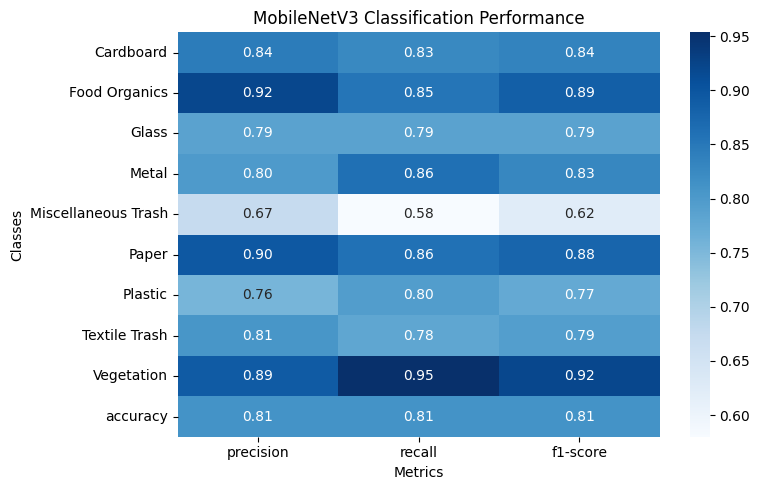

In [25]:
print_performance_table(y_true, y_pred, class_names, mnv3_model.__class__.__name__)

## Fine-Tune MV3 Model

## Print Model to see which layers to unfreeze

In [26]:
print(mnv3_model)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16

#### Unfreeze First Upper Layer

In [27]:
for param in mnv3_model.features[-1].parameters():
    param.requires_grad = True

Set up configuration for upper layer

In [28]:
train_epochs = 10
learning_rate = 0.001
mnv3_config = TrainConfig(
    epochs=train_epochs,
    lr=learning_rate,
    loss_function=nn.CrossEntropyLoss(),
    optimizer_class=torch.optim.AdamW,
    optimizer_kwargs={"weight_decay": 0.01},
    scheduler=torch.optim.lr_scheduler.CosineAnnealingLR,
    scheduler_kwargs={"T_max": train_epochs, "eta_min": learning_rate / 10},
    print_every_n_epochs=1,
)
history = train_model(
    mnv3_model,
    train,
    val,
    mnv3_config,
    device,
    checkpoint_path="best_mobilenetv3_finetuned_realwaste.pth",
    best_val_loss=history['best_val_loss'],
)

New best model saved at epoch 1 with val loss 0.5118
Epoch 1/10 | Learning rate : 1.0e-03 | Train loss: 0.5081 | Validation loss: 0.5118 
Epoch 2/10 | Learning rate : 9.8e-04 | Train loss: 0.4775 | Validation loss: 0.5151 
New best model saved at epoch 3 with val loss 0.5036
Epoch 3/10 | Learning rate : 9.1e-04 | Train loss: 0.4462 | Validation loss: 0.5036 
New best model saved at epoch 4 with val loss 0.4708
Epoch 4/10 | Learning rate : 8.1e-04 | Train loss: 0.4224 | Validation loss: 0.4708 
New best model saved at epoch 5 with val loss 0.4551
Epoch 5/10 | Learning rate : 6.9e-04 | Train loss: 0.4106 | Validation loss: 0.4551 
New best model saved at epoch 6 with val loss 0.4503
Epoch 6/10 | Learning rate : 5.5e-04 | Train loss: 0.3709 | Validation loss: 0.4503 
Epoch 7/10 | Learning rate : 4.1e-04 | Train loss: 0.3602 | Validation loss: 0.4552 
New best model saved at epoch 8 with val loss 0.4402
Epoch 8/10 | Learning rate : 2.9e-04 | Train loss: 0.3283 | Validation loss: 0.4402 
Ep

In [29]:
y_true, y_pred = test_model(mnv3_model, test, mnv3_config, class_names, device);

Test loss: 0.420092
Test Accuracy of Cardboard: 86.96% (40/46)
Test Accuracy of Food Organics: 90.24% (37/41)
Test Accuracy of Glass: 83.33% (35/42)
Test Accuracy of Metal: 83.54% (66/79)
Test Accuracy of Miscellaneous Trash: 62.00% (31/50)
Test Accuracy of Paper: 90.00% (45/50)
Test Accuracy of Plastic: 91.40% (85/93)
Test Accuracy of Textile Trash: 78.12% (25/32)
Test Accuracy of Vegetation: 97.67% (42/43)

Test Accuracy (Overall): 85.29% (406/476)


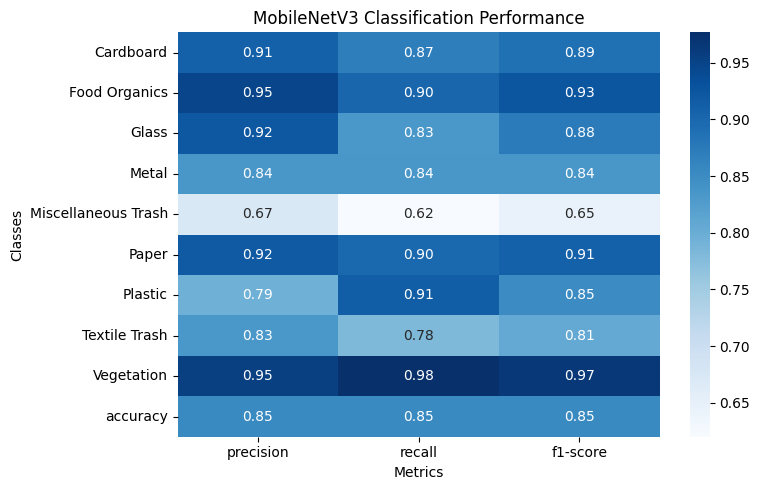

In [30]:
print_performance_table(y_true, y_pred, class_names, mnv3_model.__class__.__name__)

## Train Second Upper Layer

### Unfreeze Second Layer

In [31]:
for param in mnv3_model.features[-2].parameters():
    param.requires_grad = True

### Set up Config

In [32]:
train_epochs = 10
learning_rate = 0.0001
mnv3_config = TrainConfig(
    epochs=train_epochs,
    lr=learning_rate,
    loss_function=nn.CrossEntropyLoss(),
    optimizer_class=torch.optim.AdamW,
    optimizer_kwargs={"weight_decay": 0.01},
    scheduler=torch.optim.lr_scheduler.CosineAnnealingLR,
    scheduler_kwargs={"T_max": train_epochs, "eta_min": learning_rate / 10},
    print_every_n_epochs=1,
)
history = train_model(
    mnv3_model,
    train,
    val,
    mnv3_config,
    device,
    checkpoint_path="best_mobilenetv3_finetuned_realwaste.pth",
    best_val_loss=history['best_val_loss']
)

Epoch 1/10 | Learning rate : 1.0e-04 | Train loss: 0.3288 | Validation loss: 0.4556 
New best model saved at epoch 2 with val loss 0.4391
Epoch 2/10 | Learning rate : 9.8e-05 | Train loss: 0.3043 | Validation loss: 0.4391 
New best model saved at epoch 3 with val loss 0.4297
Epoch 3/10 | Learning rate : 9.1e-05 | Train loss: 0.2905 | Validation loss: 0.4297 
New best model saved at epoch 4 with val loss 0.4222
Epoch 4/10 | Learning rate : 8.1e-05 | Train loss: 0.2947 | Validation loss: 0.4222 
New best model saved at epoch 5 with val loss 0.4172
Epoch 5/10 | Learning rate : 6.9e-05 | Train loss: 0.2768 | Validation loss: 0.4172 
Epoch 6/10 | Learning rate : 5.5e-05 | Train loss: 0.2628 | Validation loss: 0.4198 
Epoch 7/10 | Learning rate : 4.1e-05 | Train loss: 0.2612 | Validation loss: 0.4183 
Epoch 8/10 | Learning rate : 2.9e-05 | Train loss: 0.2746 | Validation loss: 0.4184 
New best model saved at epoch 9 with val loss 0.4164
Epoch 9/10 | Learning rate : 1.9e-05 | Train loss: 0.27

In [33]:
y_true, y_pred = test_model(mnv3_model, test, mnv3_config, class_names, device)

Test loss: 0.384360
Test Accuracy of Cardboard: 84.78% (39/46)
Test Accuracy of Food Organics: 95.12% (39/41)
Test Accuracy of Glass: 83.33% (35/42)
Test Accuracy of Metal: 86.08% (68/79)
Test Accuracy of Miscellaneous Trash: 70.00% (35/50)
Test Accuracy of Paper: 90.00% (45/50)
Test Accuracy of Plastic: 93.55% (87/93)
Test Accuracy of Textile Trash: 87.50% (28/32)
Test Accuracy of Vegetation: 97.67% (42/43)

Test Accuracy (Overall): 87.82% (418/476)


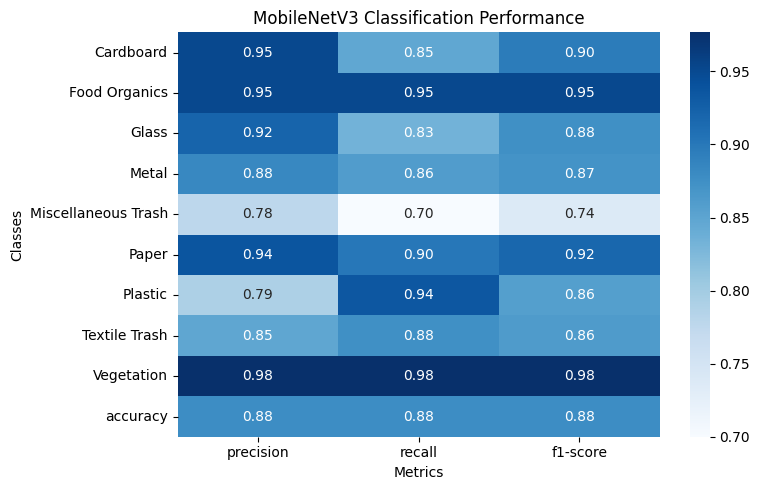

In [34]:
print_performance_table(y_true, y_pred, class_names, mnv3_model.__class__.__name__)

## Train Third Upper Layer

### Unfreeze Third Layer

In [35]:
for param in mnv3_model.features[-3].parameters():
    param.requires_grad = True

In [36]:
train_epochs = 10
learning_rate = 0.0001
mnv3_config = TrainConfig(
    epochs=train_epochs,
    lr=learning_rate,
    loss_function=nn.CrossEntropyLoss(),
    optimizer_class=torch.optim.AdamW,
    optimizer_kwargs={"weight_decay": 0.01},
    scheduler=torch.optim.lr_scheduler.CosineAnnealingLR,
    scheduler_kwargs={"T_max": train_epochs, "eta_min": learning_rate / 10},
    print_every_n_epochs=1,
)
history = train_model(
    mnv3_model,
    train,
    val,
    mnv3_config,
    device,
    checkpoint_path="best_mobilenetv3_finetuned_realwaste.pth",
    best_val_loss=history['best_val_loss']
)

New best model saved at epoch 1 with val loss 0.4088
Epoch 1/10 | Learning rate : 1.0e-04 | Train loss: 0.2659 | Validation loss: 0.4088 
New best model saved at epoch 2 with val loss 0.3933
Epoch 2/10 | Learning rate : 9.8e-05 | Train loss: 0.2551 | Validation loss: 0.3933 
New best model saved at epoch 3 with val loss 0.3858
Epoch 3/10 | Learning rate : 9.1e-05 | Train loss: 0.2386 | Validation loss: 0.3858 
New best model saved at epoch 4 with val loss 0.3756
Epoch 4/10 | Learning rate : 8.1e-05 | Train loss: 0.2243 | Validation loss: 0.3756 
Epoch 5/10 | Learning rate : 6.9e-05 | Train loss: 0.2176 | Validation loss: 0.3831 
Epoch 6/10 | Learning rate : 5.5e-05 | Train loss: 0.2110 | Validation loss: 0.3833 
Epoch 7/10 | Learning rate : 4.1e-05 | Train loss: 0.2019 | Validation loss: 0.3824 
Epoch 8/10 | Learning rate : 2.9e-05 | Train loss: 0.1980 | Validation loss: 0.3812 
Epoch 9/10 | Learning rate : 1.9e-05 | Train loss: 0.1977 | Validation loss: 0.3856 
Epoch 10/10 | Learning 

In [37]:
y_true, y_pred = test_model(mnv3_model, test, mnv3_config, class_names, device);

Test loss: 0.357231
Test Accuracy of Cardboard: 86.96% (40/46)
Test Accuracy of Food Organics: 97.56% (40/41)
Test Accuracy of Glass: 83.33% (35/42)
Test Accuracy of Metal: 92.41% (73/79)
Test Accuracy of Miscellaneous Trash: 74.00% (37/50)
Test Accuracy of Paper: 88.00% (44/50)
Test Accuracy of Plastic: 94.62% (88/93)
Test Accuracy of Textile Trash: 87.50% (28/32)
Test Accuracy of Vegetation: 100.00% (43/43)

Test Accuracy (Overall): 89.92% (428/476)


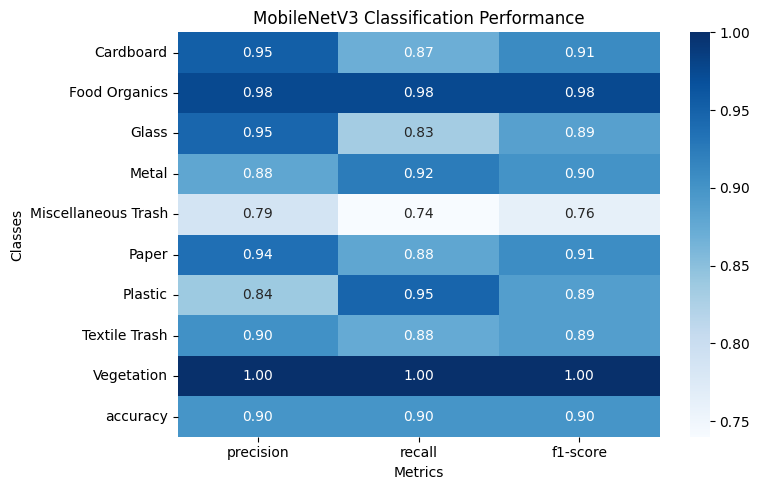

In [38]:
print_performance_table(y_true, y_pred, class_names, mnv3_model.__class__.__name__)

## Train Fourth Upper Layer

### Unfreeze Fourth Layer

In [39]:
for param in mnv3_model.features[-4].parameters():
    param.requires_grad = True

In [41]:
train_epochs = 10
learning_rate = 0.0001
mnv3_config = TrainConfig(
    epochs=train_epochs,
    lr=learning_rate,
    loss_function=nn.CrossEntropyLoss(),
    optimizer_class=torch.optim.AdamW,
    optimizer_kwargs={"weight_decay": 0.01},
    scheduler=torch.optim.lr_scheduler.CosineAnnealingLR,
    scheduler_kwargs={"T_max": train_epochs, "eta_min": learning_rate / 10},
    print_every_n_epochs=1,
)
history = train_model(
    mnv3_model,
    train,
    val,
    mnv3_config,
    device,
    checkpoint_path="best_mobilenetv3_finetuned_realwaste.pth",
    best_val_loss=history['best_val_loss']
)

Epoch 1/10 | Learning rate : 1.0e-04 | Train loss: 0.1488 | Validation loss: 0.3763 
New best model saved at epoch 2 with val loss 0.3511
Epoch 2/10 | Learning rate : 9.8e-05 | Train loss: 0.1450 | Validation loss: 0.3511 
New best model saved at epoch 3 with val loss 0.3425
Epoch 3/10 | Learning rate : 9.1e-05 | Train loss: 0.1202 | Validation loss: 0.3425 
Epoch 4/10 | Learning rate : 8.1e-05 | Train loss: 0.1117 | Validation loss: 0.3473 
New best model saved at epoch 5 with val loss 0.3399
Epoch 5/10 | Learning rate : 6.9e-05 | Train loss: 0.1014 | Validation loss: 0.3399 
New best model saved at epoch 6 with val loss 0.3345
Epoch 6/10 | Learning rate : 5.5e-05 | Train loss: 0.1085 | Validation loss: 0.3345 
New best model saved at epoch 7 with val loss 0.3277
Epoch 7/10 | Learning rate : 4.1e-05 | Train loss: 0.1088 | Validation loss: 0.3277 
Epoch 8/10 | Learning rate : 2.9e-05 | Train loss: 0.0994 | Validation loss: 0.3295 
Epoch 9/10 | Learning rate : 1.9e-05 | Train loss: 0.09

In [42]:
y_true, y_pred = test_model(mnv3_model, test, mnv3_config, class_names, device);

Test loss: 0.322278
Test Accuracy of Cardboard: 93.48% (43/46)
Test Accuracy of Food Organics: 92.68% (38/41)
Test Accuracy of Glass: 90.48% (38/42)
Test Accuracy of Metal: 88.61% (70/79)
Test Accuracy of Miscellaneous Trash: 72.00% (36/50)
Test Accuracy of Paper: 92.00% (46/50)
Test Accuracy of Plastic: 95.70% (89/93)
Test Accuracy of Textile Trash: 84.38% (27/32)
Test Accuracy of Vegetation: 100.00% (43/43)

Test Accuracy (Overall): 90.34% (430/476)


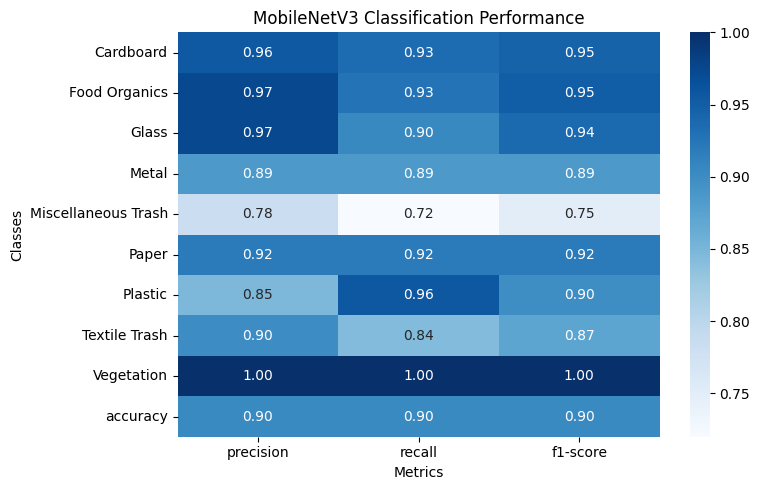

In [43]:
print_performance_table(y_true, y_pred, class_names, mnv3_model.__class__.__name__)

## Unfreeze Upper Fifth Layer

### Unfreeze Fifth Layer

In [44]:
for param in mnv3_model.features[-5].parameters():
    param.requires_grad = True

In [45]:
train_epochs = 15
learning_rate = 0.00001
mnv3_config = TrainConfig(
    epochs=train_epochs,
    lr=learning_rate,
    loss_function=nn.CrossEntropyLoss(),
    optimizer_class=torch.optim.AdamW,
    optimizer_kwargs={"weight_decay": 0.01},
    scheduler=torch.optim.lr_scheduler.CosineAnnealingLR,
    scheduler_kwargs={"T_max": train_epochs, "eta_min": learning_rate / 10},
    print_every_n_epochs=1,
)
history = train_model(
    mnv3_model,
    train,
    val,
    mnv3_config,
    device,
    checkpoint_path="best_mobilenetv3_finetuned_realwaste.pth",
    best_val_loss=history['best_val_loss']
)

New best model saved at epoch 1 with val loss 0.3202
Epoch 1/15 | Learning rate : 1.0e-05 | Train loss: 0.0905 | Validation loss: 0.3202 
New best model saved at epoch 2 with val loss 0.3181
Epoch 2/15 | Learning rate : 9.9e-06 | Train loss: 0.0841 | Validation loss: 0.3181 
Epoch 3/15 | Learning rate : 9.6e-06 | Train loss: 0.0834 | Validation loss: 0.3191 
Epoch 4/15 | Learning rate : 9.1e-06 | Train loss: 0.0876 | Validation loss: 0.3197 
Epoch 5/15 | Learning rate : 8.5e-06 | Train loss: 0.0857 | Validation loss: 0.3211 
Epoch 6/15 | Learning rate : 7.8e-06 | Train loss: 0.0905 | Validation loss: 0.3206 
Epoch 7/15 | Learning rate : 6.9e-06 | Train loss: 0.0846 | Validation loss: 0.3203 
Epoch 8/15 | Learning rate : 6.0e-06 | Train loss: 0.0837 | Validation loss: 0.3200 
Epoch 9/15 | Learning rate : 5.0e-06 | Train loss: 0.0946 | Validation loss: 0.3225 
Epoch 10/15 | Learning rate : 4.1e-06 | Train loss: 0.0808 | Validation loss: 0.3213 
Epoch 11/15 | Learning rate : 3.3e-06 | Tra

In [46]:
label_true, label_pred = test_model(mnv3_model, test, mnv3_config, class_names, device)

Test loss: 0.310703
Test Accuracy of Cardboard: 93.48% (43/46)
Test Accuracy of Food Organics: 92.68% (38/41)
Test Accuracy of Glass: 90.48% (38/42)
Test Accuracy of Metal: 88.61% (70/79)
Test Accuracy of Miscellaneous Trash: 72.00% (36/50)
Test Accuracy of Paper: 92.00% (46/50)
Test Accuracy of Plastic: 94.62% (88/93)
Test Accuracy of Textile Trash: 87.50% (28/32)
Test Accuracy of Vegetation: 100.00% (43/43)

Test Accuracy (Overall): 90.34% (430/476)


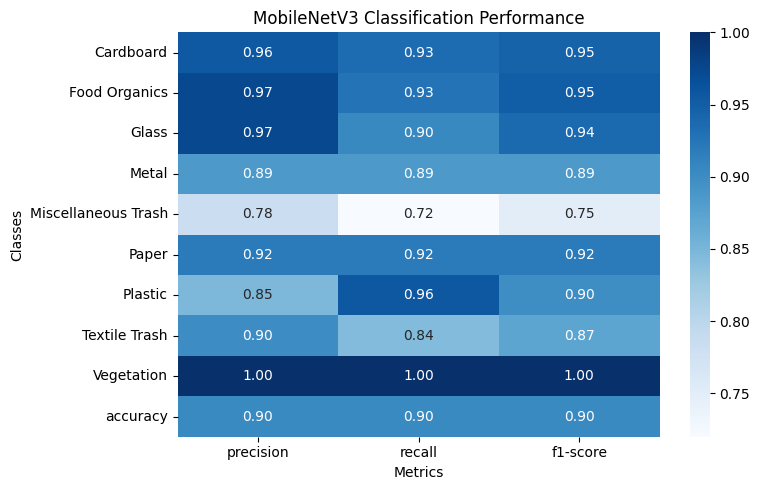

In [47]:
print_performance_table(y_true, y_pred, class_names, mnv3_model.__class__.__name__)

## Train All Layers

### Unfreeze All Layers

In [48]:
for param in mnv3_model.parameters():
    param.requires_grad = True

In [49]:
train_epochs = 20
learning_rate = 0.00001
mnv3_config = TrainConfig(
    epochs=train_epochs,
    lr=learning_rate,
    loss_function=nn.CrossEntropyLoss(),
    optimizer_class=torch.optim.AdamW,
    optimizer_kwargs={"weight_decay": 0.02},
    scheduler=torch.optim.lr_scheduler.CosineAnnealingLR,
    scheduler_kwargs={"T_max": train_epochs, "eta_min": learning_rate / 100},
    print_every_n_epochs=1,
)
history = train_model(
    mnv3_model,
    train,
    val,
    mnv3_config,
    device,
    checkpoint_path="best_mobilenetv3_unfrozen_realwaste.pth",
    best_val_loss=history['best_val_loss']
)

Epoch 1/20 | Learning rate : 1.0e-05 | Train loss: 0.0858 | Validation loss: 0.3223 
New best model saved at epoch 2 with val loss 0.3176
Epoch 2/20 | Learning rate : 9.9e-06 | Train loss: 0.0878 | Validation loss: 0.3176 
New best model saved at epoch 3 with val loss 0.3156
Epoch 3/20 | Learning rate : 9.8e-06 | Train loss: 0.0845 | Validation loss: 0.3156 
Epoch 4/20 | Learning rate : 9.5e-06 | Train loss: 0.0744 | Validation loss: 0.3169 
Epoch 5/20 | Learning rate : 9.1e-06 | Train loss: 0.0744 | Validation loss: 0.3216 
Epoch 6/20 | Learning rate : 8.6e-06 | Train loss: 0.0723 | Validation loss: 0.3196 
Epoch 7/20 | Learning rate : 8.0e-06 | Train loss: 0.0747 | Validation loss: 0.3164 
New best model saved at epoch 8 with val loss 0.3147
Epoch 8/20 | Learning rate : 7.3e-06 | Train loss: 0.0773 | Validation loss: 0.3147 
New best model saved at epoch 9 with val loss 0.3132
Epoch 9/20 | Learning rate : 6.6e-06 | Train loss: 0.0761 | Validation loss: 0.3132 
Epoch 10/20 | Learning 

#### Test Training Result

In [50]:
label_true, label_pred = test_model(mnv3_model, test, mnv3_config, class_names, device)

Test loss: 0.306166
Test Accuracy of Cardboard: 93.48% (43/46)
Test Accuracy of Food Organics: 92.68% (38/41)
Test Accuracy of Glass: 90.48% (38/42)
Test Accuracy of Metal: 88.61% (70/79)
Test Accuracy of Miscellaneous Trash: 76.00% (38/50)
Test Accuracy of Paper: 92.00% (46/50)
Test Accuracy of Plastic: 95.70% (89/93)
Test Accuracy of Textile Trash: 87.50% (28/32)
Test Accuracy of Vegetation: 100.00% (43/43)

Test Accuracy (Overall): 90.97% (433/476)


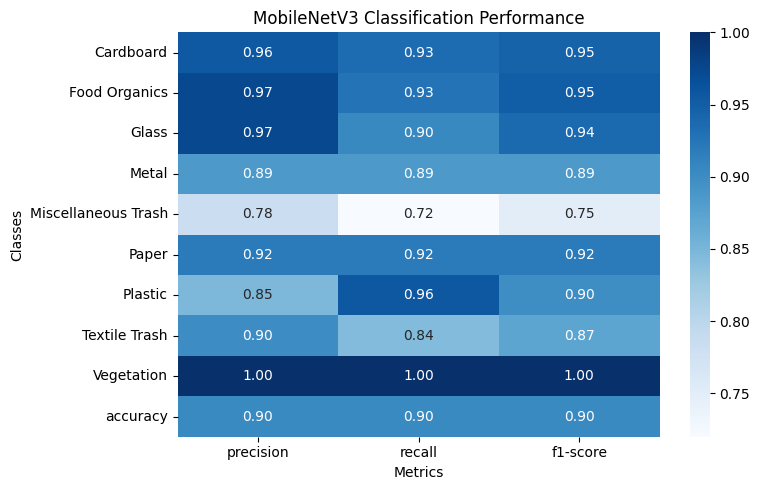

In [51]:
print_performance_table(y_true, y_pred, class_names, mnv3_model.__class__.__name__)

# Test Final Trained Model

## Load Model

In [54]:
# Create model to load weights
mnv3_model = torchvision.models.mobilenet_v3_small(weights=None, num_classes=len(class_names))
# Load checkpoint
model_path = 'best_mobilenetv3_unfrozen_realwaste.pth'
checkpoint = torch.load(model_path, weights_only=False)
# Load model with the previous saved state
mnv3_model.load_state_dict(checkpoint['model_state_dict'])
mnv3_config = checkpoint['config']
mnv3_model.eval();

## Test Model

In [60]:
y_true, y_pred = test_model(mnv3_model, test, mnv3_config,class_names, device)

Test loss: 0.307123
Test Accuracy of Cardboard: 93.48% (43/46)
Test Accuracy of Food Organics: 92.68% (38/41)
Test Accuracy of Glass: 88.10% (37/42)
Test Accuracy of Metal: 88.61% (70/79)
Test Accuracy of Miscellaneous Trash: 76.00% (38/50)
Test Accuracy of Paper: 92.00% (46/50)
Test Accuracy of Plastic: 95.70% (89/93)
Test Accuracy of Textile Trash: 87.50% (28/32)
Test Accuracy of Vegetation: 100.00% (43/43)

Test Accuracy (Overall): 90.76% (432/476)


## Display Confusion Matrix

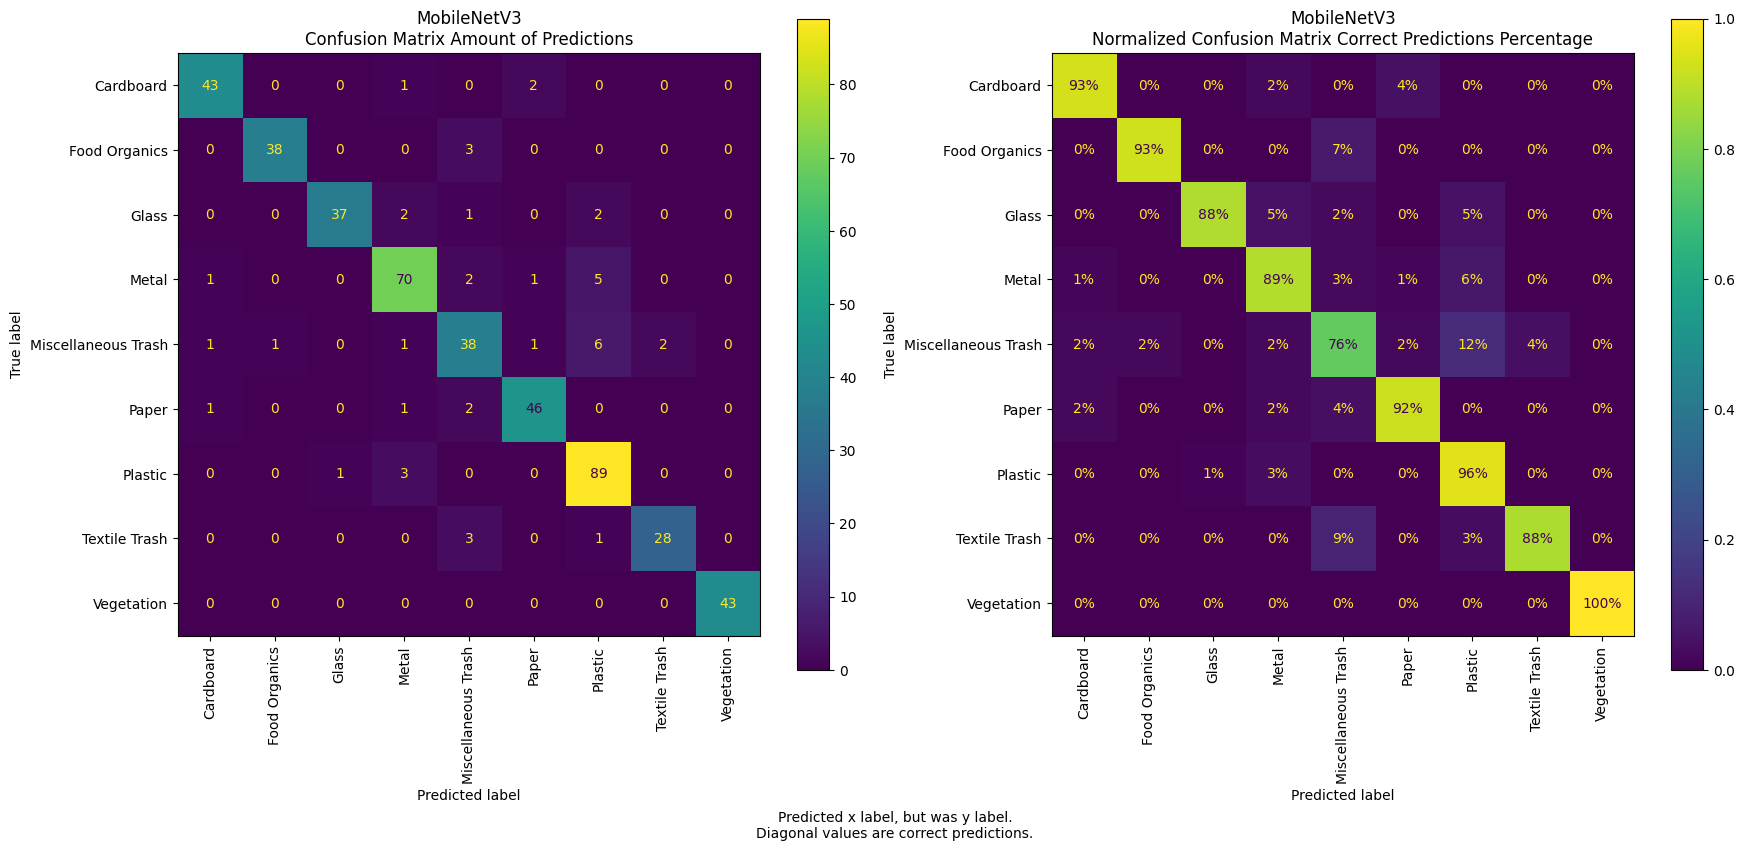

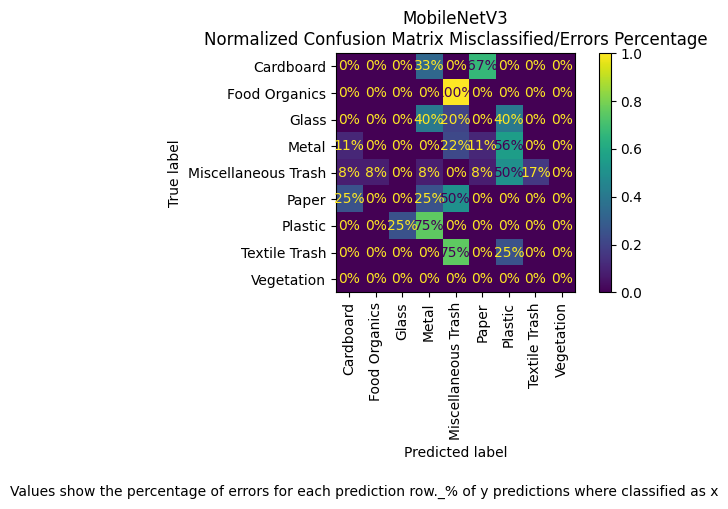

In [59]:
print_confusion_matrix(y_true, y_pred, class_names, mnv3_model.__class__.__name__)

## Display Performance Table

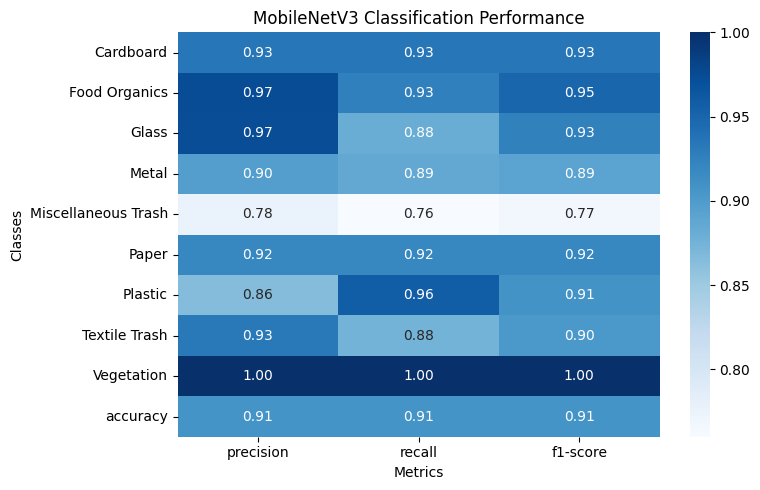

In [57]:
print_performance_table(y_true, y_pred, class_names, mnv3_model.__class__.__name__)

## Display Top-k Accuracy

In [58]:
mv3_top1, mv3_top5 = get_top_k_accuracy(mnv3_model, test, device)
print(mv3_top1, mv3_top5)

0.907563025210084 1.0
